<a href="https://colab.research.google.com/github/kiritobts500077-boop/RFM-Analysis/blob/main/RFM_Stage3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
df=pd.read_csv("RFM_Raw.csv")
df.head()

,Date,InvoNo,CustomerKey,Amount
0,2018/04/02,AP1803827,A1067,836
1,2018/04/03,AP1808235,A1129,836
2,2018/04/04,AP1807305,A1133,836
3,2018/04/05,AP1806145,A0464,836
4,2018/04/05,AP1803092,A0383,836


In [31]:
import pandas as pd

# 移除欄位名稱前後多餘的空格（解決 'Amount ' 的空白問題）
df.columns = df.columns.str.strip()

# 1. 確保Date欄位轉換為 datetime 格式
df["Date"] = pd.to_datetime(df["Date"])

# 2. 計算整個資料集的最大交易日（基準日）
max_date = df["Date"].max()

# 3. 依據CustomerKey進行聚合計算
RFM_Data = (
    df.groupby("CustomerKey")
    .agg(
        # R: 最大交易日 與 該客戶最後交易日 的天數差
        R=("Date", lambda x: (max_date - x.max()).days),
        # F: 交易次數 (計算不重複發票張數，若同一張發票有多列明細也不會重複計算)
        F=("InvoNo", "nunique"),
        # M: 交易總Amount
        M=("Amount", "sum"),
    )
    .reset_index()
)

# 4. 將「CustomerKey」欄位名稱更改為「客戶」
RFM_Data = RFM_Data.rename(columns={"CustomerKey": "客戶"})

# 調整欄位順序（客戶, R, F, M）
RFM_Data = RFM_Data[["客戶", "R", "F", "M"]]

# 檢視成果
print(RFM_Data.head())

      客戶   R   F                                                  M
0  A0350   9  25   411  334  1,214  1,183  2,100  329  329  1,86...
1  A0351  16   6               972  823  1,045  1,104  13,531  416 
2  A0352  14  14   972  334  823  1,183  1,619  1,943  731  731 ...
3  A0353  24  14   2,164  2,843  3,607  3,607  658  1,008  1,008...
4  A0354  31   6                334  2,843  2,514  3,658  252  372 


In [34]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. 確保原始 Amount 欄位轉換為正確的數值（移除逗號並轉為 float）
# 先將欄位名稱去除空白
df.columns = df.columns.str.strip()

if df['Amount'].dtype == 'object':
    # 移除字串中的逗號，並轉換為數值型態
    df['Amount'] = df['Amount'].str.replace(',', '').str.strip()
    df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# 2. 重新計算正確的 RFM_Data
max_date = df["Date"].max()
RFM_Data = (
    df.groupby("CustomerKey")
    .agg(
        R=("Date", lambda x: (max_date - x.max()).days),
        F=("InvoNo", "nunique"),
        M=("Amount", "sum"),
    )
    .reset_index()
)
RFM_Data = RFM_Data.rename(columns={"CustomerKey": "客戶"})
RFM_Data = RFM_Data[["客戶", "R", "F", "M"]]

# 3. 複製並使用 StandardScaler 進行正規化
rfmn = RFM_Data.copy()
scaler = StandardScaler()
rfmn[['R', 'F', 'M']] = scaler.fit_transform(rfmn[['R', 'F', 'M']])

# 檢視正規化後的資料
display(rfmn.head())

,客戶,R,F,M
0,A0350,-0.661105,1.347566,0.710017
1,A0351,-0.536734,-0.753785,-0.566268
2,A0352,-0.572268,0.130994,0.525804
3,A0353,-0.394595,0.130994,-0.194436
4,A0354,-0.270224,-0.753785,-0.869322


In [35]:
from sklearn.preprocessing import StandardScaler

# 複製原始資料
rfmn = RFM_Data.copy()

# 使用 StandardScaler 進行正規化
scaler = StandardScaler()
rfmn[['R', 'F', 'M']] = scaler.fit_transform(rfmn[['R', 'F', 'M']])

# 檢視正規化後的資料
print(rfmn.head())

      客戶         R         F         M
0  A0350 -0.661105  1.347566  0.710017
1  A0351 -0.536734 -0.753785 -0.566268
2  A0352 -0.572268  0.130994  0.525804
3  A0353 -0.394595  0.130994 -0.194436
4  A0354 -0.270224 -0.753785 -0.869322


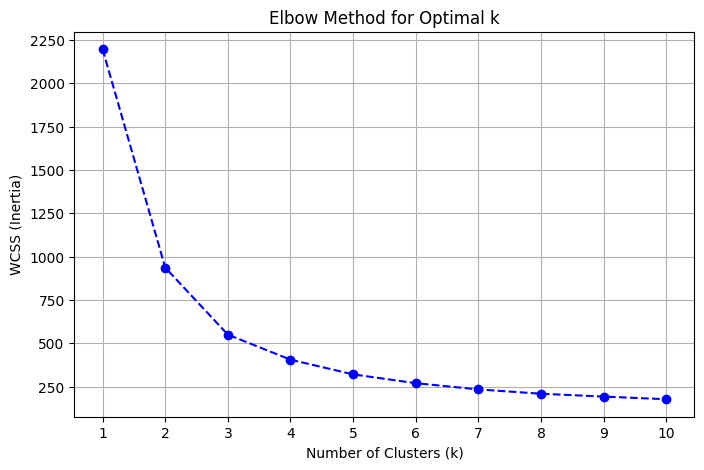

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取 RFM 特徵欄位進行 K-means 計算
X = rfmn[['R', 'F', 'M']]

wcss = []
k_range = range(1, 11)

# 計算不同 k 值下的群內誤差平方和 (Inertia)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 繪製 Elbow Chart
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [37]:
from sklearn.cluster import KMeans

# 提取 RFM 特徵
X = rfmn[['R', 'F', 'M']]

# 執行 k-means 分群 (k = 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfmn['Cluster'] = kmeans.fit_predict(X)

# 顯示各分群的數量分布
print("各分群客戶數量：")
print(rfmn['Cluster'].value_counts())

# 檢視部分結果
print("\n前 5 筆結果：")
print(rfmn.head())

各分群客戶數量：
Cluster
1    315
0    226
2    116
3     75
Name: count, dtype: int64

前 5 筆結果：
      客戶         R         F         M  Cluster
0  A0350 -0.661105  1.347566  0.710017        0
1  A0351 -0.536734 -0.753785 -0.566268        1
2  A0352 -0.572268  0.130994  0.525804        0
3  A0353 -0.394595  0.130994 -0.194436        0
4  A0354 -0.270224 -0.753785 -0.869322        1


In [45]:
rfmn

,客戶,R,F,M,Cluster
0,A0350,-0.661105,1.347566,0.710017,0
1,A0351,-0.536734,-0.753785,-0.566268,1
2,A0352,-0.572268,0.130994,0.525804,0
3,A0353,-0.394595,0.130994,-0.194436,0
4,A0354,-0.270224,-0.753785,-0.869322,1
...,...,...,...,...,...
727,A1413,-0.643338,1.126371,0.767428,0
728,A1415,-0.518966,0.794579,0.778298,0
729,A1416,-0.749942,1.236968,0.660299,0
730,A1419,0.067356,1.015774,1.208383,2


In [46]:
# 載入 Silhouette 套件，為驗證分組成效，需要執行 Silhouette 分析
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(rfmn[["R","F","M"]],rfmn.Cluster)

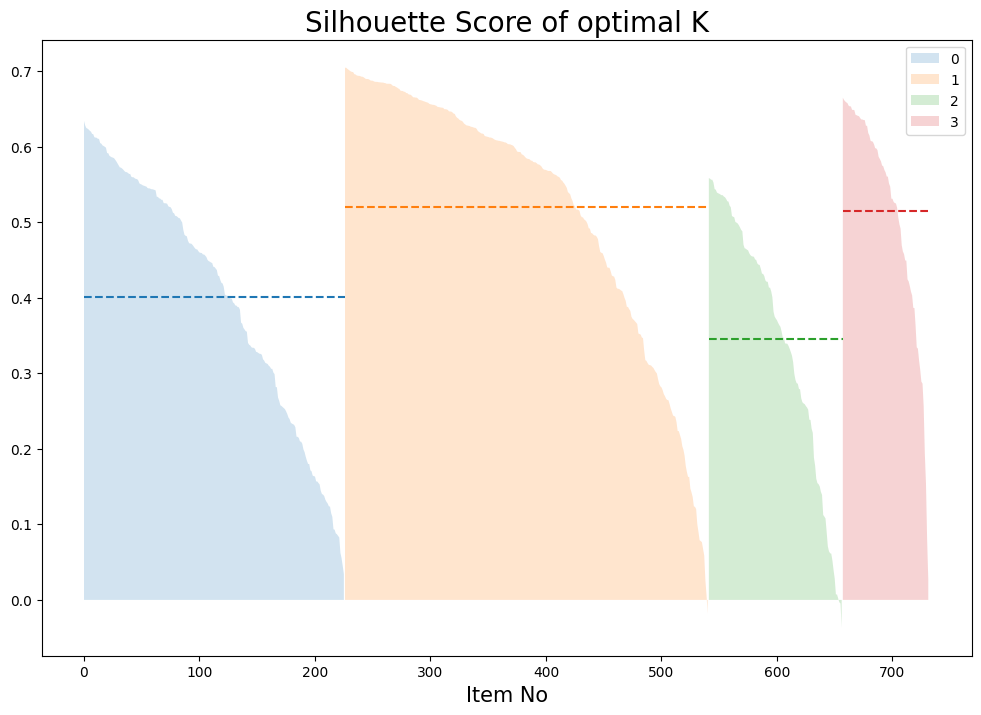

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

k=4 #承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):

    group_slh=silhouette[rfmn.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿

    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線

    plt.legend() # 繪製圖例

    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)
plt.show()

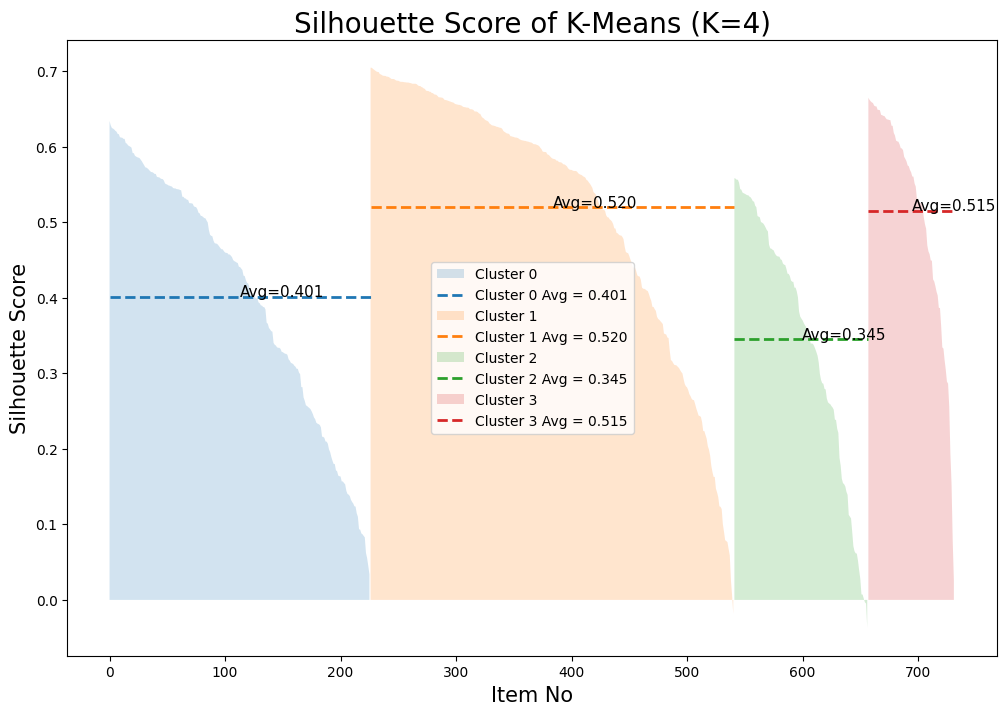

In [51]:
k = 4

plt.figure(figsize=(12, 8))
x0 = 0

for i in range(k):

    # 取得第 i 組 Silhouette Score
    group_slh = silhouette[rfmn.Cluster == i]

    # X 軸
    x = range(x0, x0 + len(group_slh))

    # Silhouette Score 由大到小
    y = -np.sort(-group_slh)

    # 第 i 組平均值
    yavg = np.average(group_slh)

    # 繪製 Silhouette 區域
    plt.fill_between(
        x, y,
        alpha=0.2,
        label=f'Cluster {i}'
    )

    # ★ 顯示該組平均線
    plt.plot(
        [x0, x0 + len(group_slh)],
        [yavg, yavg],
        '--',
        linewidth=2,
        label=f'Cluster {i} Avg = {yavg:.3f}'
    )

    # ★ 在圖上直接顯示平均數字
    plt.text(
        x0 + len(group_slh) / 2,
        yavg,
        f'Avg={yavg:.3f}',
        fontsize=11
    )

    x0 = x0 + len(group_slh)

plt.title('Silhouette Score of K-Means (K=4)', fontsize=20)
plt.xlabel('Item No', fontsize=15)
plt.ylabel('Silhouette Score', fontsize=15)

plt.legend()
plt.show()

In [43]:
kmeans.labels_

array([0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 3, 1, 0, 1, 0, 0, 1, 2, 3, 2, 3, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 3, 0, 1, 1, 1, 2, 1, 1, 0, 2, 0, 0,
       3, 1, 0, 1, 1, 0, 1, 3, 1, 0, 2, 0, 0, 3, 1, 3, 1, 0, 0, 1, 1, 0,
       2, 1, 1, 0, 3, 1, 1, 1, 0, 0, 0, 3, 2, 0, 2, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 2, 0, 2, 0, 1, 1, 1, 0,
       1, 1, 3, 2, 2, 3, 0, 1, 1, 0, 0, 3, 1, 3, 1, 1, 1, 1, 1, 2, 1, 0,
       0, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2, 3, 2, 1, 0,
       2, 1, 3, 1, 1, 3, 0, 2, 2, 2, 0, 1, 1, 1, 1, 2, 1, 0, 3, 1, 3, 3,
       0, 0, 0, 2, 1, 1, 0, 3, 1, 0, 1, 3, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       2, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 2, 1, 1, 1, 1, 0, 1, 2, 1, 3,
       0, 0, 1, 1, 3, 3, 2, 1, 3, 3, 0, 1, 3, 1, 2, 2, 0, 0, 1, 0, 0, 1,
       2, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 3, 0, 1, 0, 0, 1, 1, 1, 2, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 2, 0, 2,

In [44]:
# 將 rfmn 中的 Cluster 標籤複製回 RFM_Data
RFM_Data['Cluster'] = rfmn['Cluster']

# 檢視合併後的原始 RFM 資料
print(RFM_Data.head())

      客戶   R   F      M  Cluster Group
0  A0350   9  25  51237        0     M
1  A0351  16   6  17891        1     L
2  A0352  14  14  46424        0     M
3  A0353  24  14  27606        0     M
4  A0354  31   6   9973        1     L


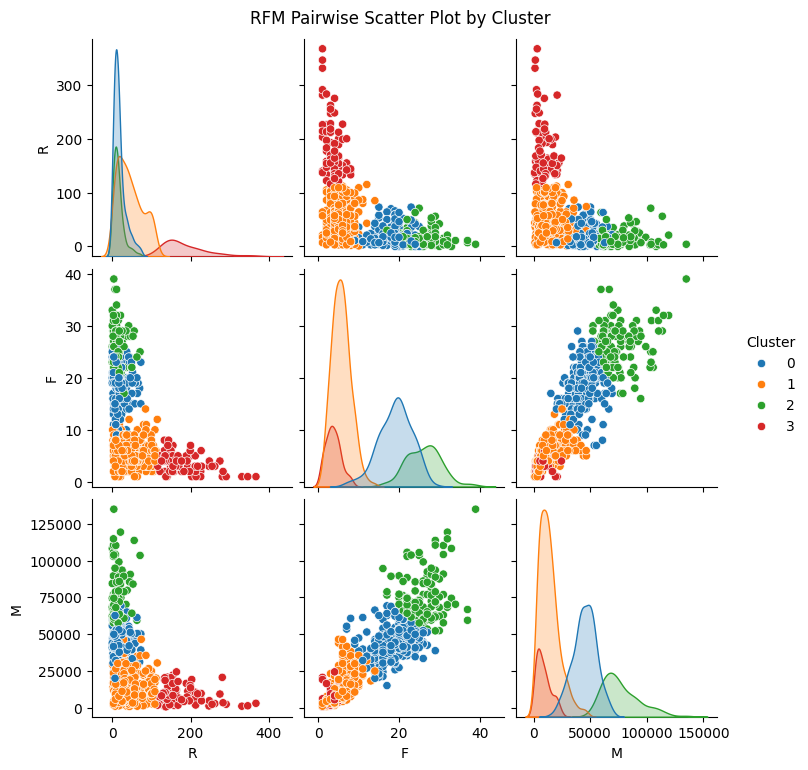

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用 Seaborn 繪製成對散布圖，並依 Cluster 欄位進行著色分群
sns.pairplot(RFM_Data, vars=['R', 'F', 'M'], hue='Cluster', palette='tab10', diag_kind='kde')
plt.suptitle('RFM Pairwise Scatter Plot by Cluster', y=1.02)
plt.show()

In [40]:
# 定義 Cluster 對應 Group 的對照表
group_mapping = {
    0: 'M',
    1: 'L',
    2: 'H',
    3: 'Missing'
}

# 新增 Group 欄位
RFM_Data['Group'] = RFM_Data['Cluster'].map(group_mapping)

# 檢視更新後的資料與各組別數量
print(RFM_Data['Group'].value_counts())
print("\n資料預覽：")
print(RFM_Data.head())

Group
L          315
M          226
H          116
Missing     75
Name: count, dtype: int64

資料預覽：
      客戶   R   F      M  Cluster Group
0  A0350   9  25  51237        0     M
1  A0351  16   6  17891        1     L
2  A0352  14  14  46424        0     M
3  A0353  24  14  27606        0     M
4  A0354  31   6   9973        1     L


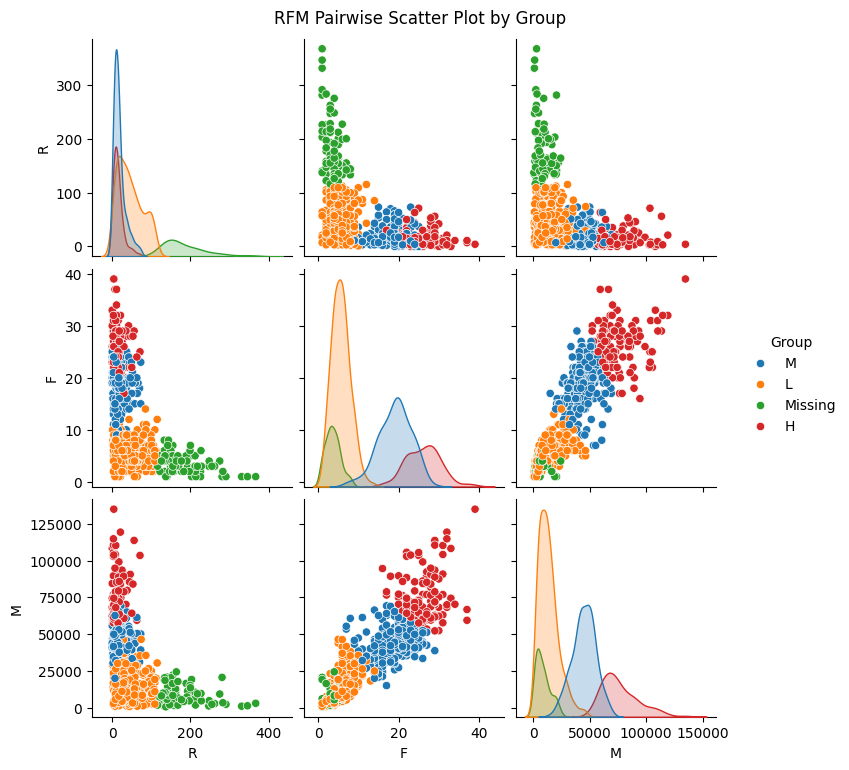

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用 Seaborn 繪製成對散布圖，並依 Group 欄位進行著色分群
g = sns.pairplot(RFM_Data, vars=['R', 'F', 'M'], hue='Group', palette='tab10', diag_kind='kde')
plt.suptitle('RFM Pairwise Scatter Plot by Group', y=1.02)

# 匯出為透明背景的 PNG 格式
g.savefig('RFM_Pair.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
Silhouette

In [42]:
# 將 RFM_Data 匯出成 CSV 檔案，不保留 index
RFM_Data.to_csv('RFM_Res.csv', index=False)
print("已成功匯出至 RFM_Res.csv")

已成功匯出至 RFM_Res.csv
